In [5]:
# ==========================================================
# Imports
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

# Linear Programming solver
from scipy.optimize import linprog
print("Imports successful! \nPret")

Imports successful! 
Pret


In [6]:
# ==========================================================
# Load yearly data
# ==========================================================

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()

pv_factor = pv_mat["zeta_PV"].flatten()

price_year = price_mat["prices_all_year"].flatten()

print("Data loaded successfully")

Data loaded successfully


In [ ]:
# ==========================================================
# Select representative day
# ==========================================================

# We start with the most challenging scenario:
# High-demand EV day

DAY = 95  # maximum load day in the year

start_idx = (DAY - 1) * 24
end_idx = DAY * 24

load_day = load_year[start_idx:end_idx]

pv_factor_day = pv_factor[start_idx:end_idx]

price_day = price_year[start_idx:end_idx]

print("Selected day:", DAY)

Selected day: 95


In [8]:
# ==========================================================
# Define fixed PV and BESS sizes
# ==========================================================

# Later these become optimization variables.
# For now they are fixed parameters.

S_PV = 300      # kWp
E_BESS = 200    # kWh

pv_day = S_PV * pv_factor_day

print("PV size [kWp]:", S_PV)
print("BESS capacity [kWh]:", E_BESS)

PV size [kWp]: 300
BESS capacity [kWh]: 200


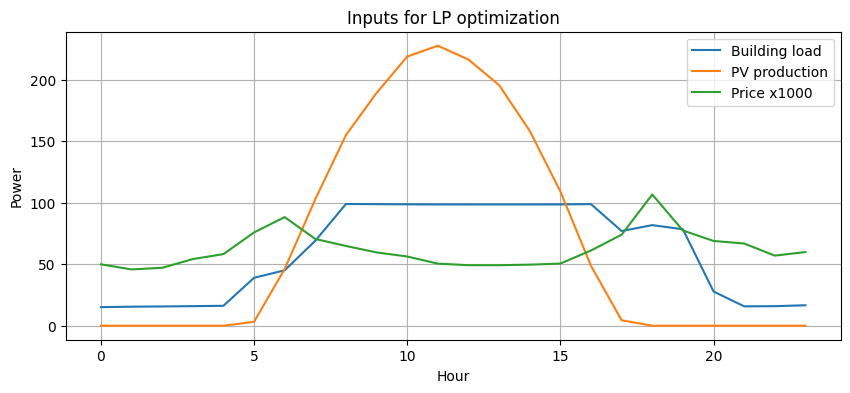

In [9]:
# ==========================================================
# Visualize optimization inputs
# ==========================================================

plt.figure(figsize=(10,4))

plt.plot(load_day, label="Building load")
plt.plot(pv_day, label="PV production")
plt.plot(price_day*1000, label="Price x1000")

plt.title("Inputs for LP optimization")
plt.xlabel("Hour")
plt.ylabel("Power")

plt.legend()
plt.grid()

plt.show()

In [10]:
# ==========================================================
# LP MODEL PARAMETERS
# ==========================================================
#
# We solve a 24-hour daily scheduling problem.
#
# Decision variables:
# - Battery charging power
# - Battery discharging power
# - Battery energy/SOC
# - Grid import
# - Grid export
#
# Objective:
# Minimize electricity cost.
# ==========================================================

N = 24
dt = 1.0   # [h]

P_bess_max = 50.0
eta_ch = 0.95
eta_dis = 0.95

SOC_min = 0.10 * E_BESS
SOC_max = 0.90 * E_BESS
SOC0 = 0.50 * E_BESS

p_grid_fee_import = 0.05
p_grid_fee_export = -0.01

p_buy = price_day + p_grid_fee_import
p_sell = 0.9 * price_day + p_grid_fee_export

c_deg = 0.01  # simple battery degradation cost [EUR/kWh]

In [11]:
# ==========================================================
# VARIABLE INDEXING
# ==========================================================
#
# x = [
#   P_ch[0:24],
#   P_dch[0:24],
#   SOC[0:25],
#   P_grid_import[0:24],
#   P_grid_export[0:24]
# ]
# ==========================================================

idx_ch_start = 0
idx_dch_start = idx_ch_start + N
idx_soc_start = idx_dch_start + N
idx_grid_import_start = idx_soc_start + (N + 1)
idx_grid_export_start = idx_grid_import_start + N

n_vars = idx_grid_export_start + N

print("Number of optimization variables:", n_vars)

Number of optimization variables: 121


In [12]:
# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================
#
# Minimize:
#
# Cost of grid import
# - Revenue from grid export
# + Battery degradation cost
# ==========================================================

c = np.zeros(n_vars)

for k in range(N):

    c[idx_ch_start + k] = c_deg
    c[idx_dch_start + k] = c_deg

    c[idx_grid_import_start + k] = p_buy[k]
    c[idx_grid_export_start + k] = -p_sell[k]

In [13]:
# ==========================================================
# EQUALITY CONSTRAINTS
# ==========================================================
#
# We need two types of equality constraints:
#
# 1) Power balance for every hour:
#
#    load + P_ch - P_dch = PV + grid_import - grid_export
#
# Rearranged:
#
#    P_ch - P_dch - grid_import + grid_export = PV - load
#
#
# 2) Battery SOC dynamics:
#
#    SOC[k+1] = SOC[k] + eta_ch*P_ch[k]*dt
#                        - P_dch[k]*dt/eta_dis
#
# Rearranged:
#
#    SOC[k+1] - SOC[k]
#    - eta_ch*P_ch[k]*dt
#    + P_dch[k]*dt/eta_dis = 0
#
# 3) Initial SOC:
#
#    SOC[0] = SOC0
# ==========================================================

A_eq = []
b_eq = []

# ----------------------------------------------------------
# 1) Power balance constraints
# ----------------------------------------------------------

for k in range(N):

    row = np.zeros(n_vars)

    row[idx_ch_start + k] = 1.0
    row[idx_dch_start + k] = -1.0

    row[idx_grid_import_start + k] = -1.0
    row[idx_grid_export_start + k] = 1.0

    A_eq.append(row)

    b_eq.append(pv_day[k] - load_day[k])


# ----------------------------------------------------------
# 2) Battery SOC dynamics
# ----------------------------------------------------------

for k in range(N):

    row = np.zeros(n_vars)

    row[idx_soc_start + k + 1] = 1.0
    row[idx_soc_start + k] = -1.0

    row[idx_ch_start + k] = -eta_ch * dt

    row[idx_dch_start + k] = dt / eta_dis

    A_eq.append(row)

    b_eq.append(0.0)


# ----------------------------------------------------------
# 3) Initial SOC constraint
# ----------------------------------------------------------

row = np.zeros(n_vars)

row[idx_soc_start] = 1.0

A_eq.append(row)
b_eq.append(SOC0)


# Convert lists to numpy arrays for scipy.optimize.linprog

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)

A_eq shape: (49, 121)
b_eq shape: (49,)


Bounds 

In [14]:
# ==========================================================
# VARIABLE BOUNDS
# ==========================================================
#
# Bounds define the minimum and maximum allowed value
# for every decision variable.
#
# P_ch:
#   0 <= P_ch <= P_bess_max
#
# P_dch:
#   0 <= P_dch <= P_bess_max
#
# SOC:
#   SOC_min <= SOC <= SOC_max
#
# Grid import:
#   P_grid_import >= 0
#
# Grid export:
#   P_grid_export >= 0
# ==========================================================

bounds = []

# Battery charging power bounds
for k in range(N):
    bounds.append((0, P_bess_max))

# Battery discharging power bounds
for k in range(N):
    bounds.append((0, P_bess_max))

# Battery SOC bounds
for k in range(N + 1):
    bounds.append((SOC_min, SOC_max))

# Grid import bounds
for k in range(N):
    bounds.append((0, None))

# Grid export bounds
for k in range(N):
    bounds.append((0, None))

print("Number of bounds:", len(bounds))

Number of bounds: 121


Solve LP

In [15]:
# ==========================================================
# SOLVE LINEAR PROGRAM
# ==========================================================
#
# scipy.optimize.linprog solves:
#
# min c^T x
#
# subject to:
#   A_eq x = b_eq
#   bounds on x
#
# We use the HiGHS solver backend.
# ==========================================================

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)
print("Optimal cost [EUR]:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal cost [EUR]: 11.081337686278966


Extract Solution

In [20]:
# ==========================================================
# Hour vector for plotting
# ==========================================================

hours = np.arange(24)

print(hours)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


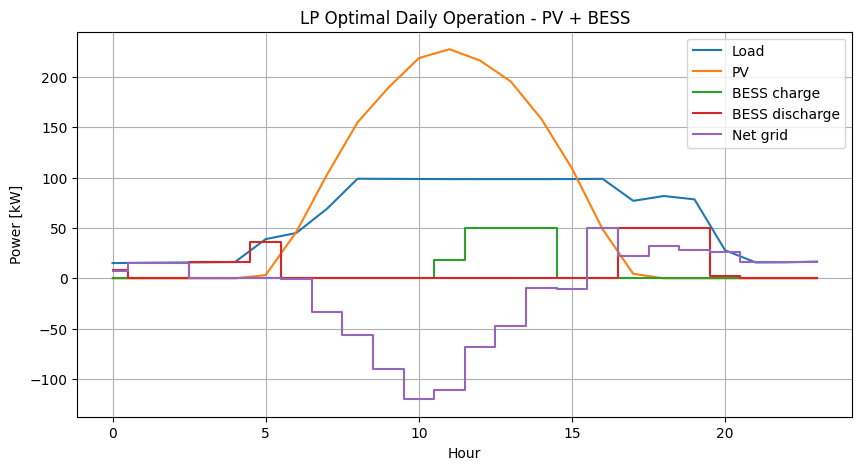

In [ ]:
# ==========================================================
# PLOT OPTIMAL DAILY OPERATION
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(hours, load_day, label="Load")
plt.plot(hours, pv_day, label="PV")
plt.step(hours, P_ch_opt, where="mid", label="BESS charge")
plt.step(hours, P_dch_opt, where="mid", label="BESS discharge") 
plt.step(hours, P_grid_net_opt, where="mid", label="Net grid")

plt.xlabel("Hour")
plt.ylabel("Power [kW]")
plt.title("LP Optimal Daily Operation - PV + BESS")
plt.grid()
plt.legend()

plt.show()

SOC PLOT

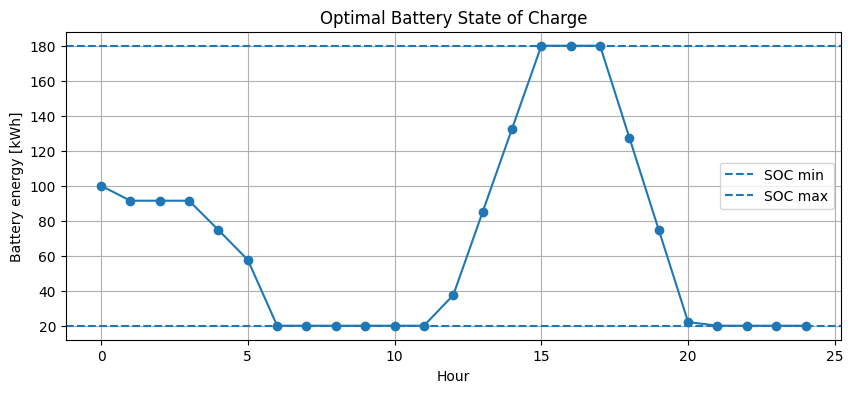

In [22]:
# ==========================================================
# PLOT OPTIMAL BATTERY SOC
# ==========================================================

plt.figure(figsize=(10,4))

plt.plot(np.arange(N + 1), SOC_opt, marker="o")
plt.axhline(SOC_min, linestyle="--", label="SOC min")
plt.axhline(SOC_max, linestyle="--", label="SOC max")

plt.xlabel("Hour")
plt.ylabel("Battery energy [kWh]")
plt.title("Optimal Battery State of Charge")
plt.grid()
plt.legend()

plt.show()

Fixed ASAP ~ EV charging Profiles.